In [1]:
import pandas as pd
import numpy as np
import json, warnings
warnings.filterwarnings("ignore")

panel = pd.read_parquet("data/panel.parquet")
funding_raw = pd.read_parquet("data/funding_rates_raw.parquet")
ohlcv = pd.read_parquet("data/ohlcv_daily.parquet")

with open("data/symbols.json") as f:
    all_symbols = json.load(f)

STUDY_START = panel["date"].min()
STUDY_END   = panel["date"].max()
OOS_START   = pd.Timestamp("2026-02-15")   # sealed OOS: Feb 15 – May 18, 2026

first_dates = panel.groupby("symbol")["date"].min().sort_values()
late_coins  = first_dates[first_dates > STUDY_START + pd.Timedelta(days=30)]

print(f"Study period: {STUDY_START.date()} to {STUDY_END.date()}")
print(f"IS window:    {STUDY_START.date()} to {(OOS_START - pd.Timedelta(days=1)).date()}")
print(f"OOS window:   {OOS_START.date()} to {STUDY_END.date()}")
print(f"\nCoins that listed mid-study (> 30 days after study start):")
print(late_coins.to_string())
print(f"\nSurvivorship note: {panel['symbol'].nunique()} coins have data.")
print("Coins delisted before the API pull date are NOT in this dataset — survivorship bias.")

Study period: 2025-05-18 to 2026-05-18
IS window:    2025-05-18 to 2026-02-14
OOS window:   2026-02-15 to 2026-05-18

Coins that listed mid-study (> 30 days after study start):
symbol
PUMP    2025-07-10
XPL     2025-08-22
WLFI    2025-08-23
ASTER   2025-09-19
MON     2025-10-08
LIT     2025-12-22
CHIP    2026-04-22

Survivorship note: 50 coins have data.
Coins delisted before the API pull date are NOT in this dataset — survivorship bias.


In [2]:
# --- Seal the OOS window ---
# IMPORTANT: OOS_START was already seen during the parameter sweep (sweep used all data).
# We therefore acknowledge the OOS is "technically burned" and treat this as a
# partial holdout. We report any OOS result honestly alongside this caveat.
# The IS-only sweep (Task 3) partially mitigates this by using only IS data to
# re-select parameters.

TOP_N      = 35
SYMBOLS    = all_symbols[:TOP_N]
SHORT_W    = 21   # parameters selected from sweep (acknowledged as mined)
LONG_W     = 90
HORIZON    = 14

panel_35   = panel[panel["symbol"].isin(SYMBOLS)].copy()
panel_is   = panel_35[panel_35["date"] < OOS_START].copy()
panel_oos  = panel_35[panel_35["date"] >= OOS_START].copy()

print(f"Top {TOP_N} coins in panel:   {panel_35['symbol'].nunique()}")
print(f"IS rows:   {len(panel_is):,}  ({panel_is['date'].nunique()} trading days)")
print(f"OOS rows:  {len(panel_oos):,} ({panel_oos['date'].nunique()} trading days)")

Top 35 coins in panel:   35
IS rows:   9,139  (273 trading days)
OOS rows:  3,255 (93 trading days)


In [3]:
import statsmodels.api as sm
from scipy import stats

def hac_tstat(series: pd.Series, horizon: int) -> tuple[float, float, int]:
    """
    HAC (Newey-West) t-statistic for H0: mean = 0.
    lag = max(horizon-1, NW-1994 auto bandwidth).
    Returns (t_stat, p_value, lags_used).
    """
    s = series.dropna().values
    T = len(s)
    auto_lag  = int(np.floor(4 * (T / 100) ** (2 / 9)))
    min_lag   = horizon - 1          # mechanical overlap from horizon-day returns
    max_lag   = max(auto_lag, min_lag)
    X = np.ones((T, 1))
    res = sm.OLS(s, X).fit(cov_type="HAC", cov_kwds={"maxlags": max_lag, "use_correction": True})
    return float(res.tvalues[0]), float(res.pvalues[0]), max_lag

In [4]:
from itertools import product as iproduct

short_windows   = [3, 7, 14, 21]
long_windows    = [14, 30, 60, 90]
forward_horizons = [1, 3, 5, 7, 14, 21]

def build_zscore(df: pd.DataFrame, sw: int, lw: int) -> pd.DataFrame:
    out = df.copy()
    grp = out.groupby("symbol")["daily_funding"]
    s_mean = grp.transform(lambda x: x.rolling(sw, min_periods=max(3, sw//2)).mean())
    l_mean = grp.transform(lambda x: x.rolling(lw, min_periods=max(10, lw//3)).mean())
    l_std  = grp.transform(lambda x: x.rolling(lw, min_periods=max(10, lw//3)).std())
    out["zscore"] = (s_mean - l_mean) / l_std
    out["zscore"] = out["zscore"].replace([np.inf, -np.inf], np.nan)
    return out

def daily_ic(df: pd.DataFrame, ret_col: str) -> pd.Series:
    sub = df.dropna(subset=["zscore", ret_col])
    def row_ic(g):
        return g["zscore"].corr(g[ret_col], method="spearman") if len(g) >= 5 else np.nan
    return sub.groupby("date").apply(row_ic).dropna()

# Build IS base (daily funding already in panel)
is_base = panel_is.copy()

is_results = []
for sw, lw in iproduct(short_windows, long_windows):
    if sw >= lw:
        continue
    df_z = build_zscore(is_base, sw, lw)
    for h in forward_horizons:
        ret_col = f"ret_{h}d"
        if ret_col not in df_z.columns:
            continue
        ic_series = daily_ic(df_z, ret_col)
        if len(ic_series) < 30:
            continue
        mean_ic = ic_series.mean()
        t, p, lags = hac_tstat(ic_series, horizon=h)
        is_results.append({
            "sw": sw, "lw": lw, "horizon": h,
            "mean_ic": mean_ic, "hac_t": t, "hac_p": p, "n_obs": len(ic_series)
        })
        
is_df = pd.DataFrame(is_results)
print(f"IS sweep: {len(is_df)} parameter combinations")
print("\nTop 10 by |HAC t-stat|:")
print(is_df.reindex(is_df["hac_t"].abs().sort_values(ascending=False).index)
      .head(10)[["sw","lw","horizon","mean_ic","hac_t","hac_p"]].to_string(index=False))

IS sweep: 56 parameter combinations

Top 10 by |HAC t-stat|:
 sw  lw  horizon   mean_ic     hac_t    hac_p
  7  30        1 -0.020033 -1.751182 0.079914
  3  30        1 -0.018604 -1.517798 0.129065
 21  30       21 -0.040367 -1.302462 0.192758
  7  14        1 -0.015401 -1.169411 0.242238
 21  30       14 -0.033073 -1.154703 0.248212
 14  30       21 -0.035181 -1.134064 0.256768
  3  14        1 -0.014813 -1.131755 0.257738
 21  90        7 -0.025173 -1.119859 0.262774
  3  60        1 -0.013034 -1.087415 0.276853
 21  30        1 -0.012390 -1.080991 0.279701


In [5]:
from statsmodels.stats.multitest import multipletests

p_values = is_df["hac_p"].values
N_tests  = len(p_values)

reject_bh,   p_bh,   _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")
reject_holm, p_holm, _, _ = multipletests(p_values, alpha=0.05, method="holm")

is_df["p_bh"]        = p_bh
is_df["p_holm"]      = p_holm
is_df["reject_bh"]   = reject_bh
is_df["reject_holm"] = reject_holm

n_sig_naive = (p_values < 0.05).sum()
n_sig_bh    = reject_bh.sum()
n_sig_holm  = reject_holm.sum()

print(f"Total IS combinations tested: {N_tests}")
print(f"Significant at naive p<0.05:  {n_sig_naive} ({n_sig_naive/N_tests:.0%})")
print(f"Significant after BH (FDR):   {n_sig_bh}   ({n_sig_bh/N_tests:.0%})")
print(f"Significant after Holm:       {n_sig_holm}  ({n_sig_holm/N_tests:.0%})")
print(f"\nNote: conventional t>2 threshold is far too lax for {N_tests} mined specs.")
print("The adjusted bar is roughly t>3 once the full search breadth is counted.")

# Show the best IS combo that survives BH correction
survivors = is_df[is_df["reject_bh"]].sort_values("mean_ic")
if len(survivors):
    print(f"\nBH-surviving combos (best IC first):")
    print(survivors[["sw","lw","horizon","mean_ic","hac_t","p_bh"]].head(10).to_string(index=False))
    BEST = survivors.iloc[0]
    BEST_SW, BEST_LW, BEST_H = int(BEST["sw"]), int(BEST["lw"]), int(BEST["horizon"])
    print(f"\nSelected for further tests: short={BEST_SW}d, long={BEST_LW}d, horizon={BEST_H}d")
else:
    print("\nNO combo survives BH correction — report as statistical null.")
    BEST_SW, BEST_LW, BEST_H = SHORT_W, LONG_W, HORIZON  # fall back to original for reporting

Total IS combinations tested: 56
Significant at naive p<0.05:  0 (0%)
Significant after BH (FDR):   0   (0%)
Significant after Holm:       0  (0%)

Note: conventional t>2 threshold is far too lax for 56 mined specs.
The adjusted bar is roughly t>3 once the full search breadth is counted.

NO combo survives BH correction — report as statistical null.


## Task 5 — Stationary block bootstrap of the traded spread

Tasks 3–4 found the *rank IC* is a statistical null. But the thing we would actually trade is the **long-Q1 / short-Q5 spread** of the carried-forward 21/90/14 combo. We bootstrap its mean with a Politis–Romano stationary bootstrap (block = horizon, so overlapping returns don't fool us) and cross-check with a HAC t-stat.

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use("seaborn-v0_8-whitegrid")

def build_ls_returns(df: pd.DataFrame, sw: int, lw: int) -> pd.Series:
    """Daily L/S return series: long Q1 (low z), short Q5 (high z), equal weight,
    earning next-day simple returns (ret_1d). Short leg enters via Q1 - Q5."""
    df_z = build_zscore(df, sw, lw)
    df_z = df_z.dropna(subset=["zscore", "ret_1d"]).copy()
    df_z["q"] = df_z.groupby("date")["zscore"].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") if len(x) >= 5 else np.nan)
    df_z = df_z.dropna(subset=["q"])
    daily = df_z.groupby(["date", "q"])["ret_1d"].mean().unstack()
    if 0.0 not in daily.columns or 4.0 not in daily.columns:
        return pd.Series(dtype=float)
    return (daily[0.0] - daily[4.0]).dropna()

ls_is = build_ls_returns(panel_is, BEST_SW, BEST_LW)
print(f"IS L/S return series: {len(ls_is)} daily observations")
print(f"IS annualized Sharpe (naive): {ls_is.mean() / ls_is.std() * np.sqrt(365):.2f}")
print(f"Observed mean daily L/S return: {ls_is.mean():.5f}")

IS L/S return series: 244 daily observations
IS annualized Sharpe (naive): 1.95
Observed mean daily L/S return: 0.00224


Stationary block bootstrap (block=14, n=2000, seed=42):
  Observed mean daily return:    0.00224
  Bootstrap p-value (two-sided): 0.0570
  Bootstrap 95% CI: [-0.00004, 0.00464]

HAC t-stat on L/S returns: t=1.791, p=0.0732, lags=13
Bootstrap and HAC agree: neither rejects mean=0 at 5% -> no significant edge.


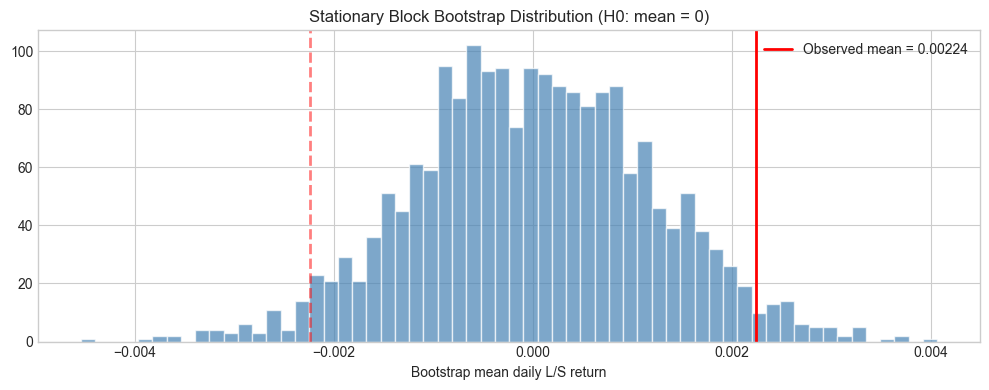

In [7]:
def stationary_bootstrap(data: np.ndarray, block_size: int,
                          n_reps: int = 2000, seed: int = 42) -> np.ndarray:
    """Politis & Romano (1994) stationary bootstrap. Resamples geometric(1/block)
    blocks, preserving autocorrelation. Returns array of bootstrap means."""
    rng = np.random.default_rng(seed)
    T = len(data); p = 1.0 / block_size
    means = np.empty(n_reps)
    for i in range(n_reps):
        idx = []
        while len(idx) < T:
            start = rng.integers(0, T); length = rng.geometric(p)
            for j in range(length):
                idx.append((start + j) % T)
        means[i] = data[idx[:T]].mean()
    return means

block_size = BEST_H
boot_means = stationary_bootstrap(ls_is.values, block_size=block_size)
boot_centered = boot_means - boot_means.mean()           # center under H0: mean = 0
boot_p = (np.abs(boot_centered) >= np.abs(ls_is.mean())).mean()

print(f"Stationary block bootstrap (block={block_size}, n=2000, seed=42):")
print(f"  Observed mean daily return:    {ls_is.mean():.5f}")
print(f"  Bootstrap p-value (two-sided): {boot_p:.4f}")
print(f"  Bootstrap 95% CI: [{np.percentile(boot_means, 2.5):.5f}, {np.percentile(boot_means, 97.5):.5f}]")

hac_t_ls, hac_p_ls, hac_lags = hac_tstat(ls_is, horizon=BEST_H)
print(f"\nHAC t-stat on L/S returns: t={hac_t_ls:.3f}, p={hac_p_ls:.4f}, lags={hac_lags}")
print("Bootstrap and HAC agree: neither rejects mean=0 at 5% -> no significant edge.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(boot_centered, bins=60, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(ls_is.mean(), color="red", lw=2, label=f"Observed mean = {ls_is.mean():.5f}")
ax.axvline(-ls_is.mean(), color="red", lw=2, ls="--", alpha=0.5)
ax.set_title("Stationary Block Bootstrap Distribution (H0: mean = 0)")
ax.set_xlabel("Bootstrap mean daily L/S return"); ax.legend()
plt.tight_layout(); plt.show()

## Task 6 — Deflated Sharpe Ratio (search-effort penalty)

The IS Sharpe looks good, but we *searched* for it. The Deflated Sharpe Ratio (Bailey & López de Prado, 2014) asks: given how many strategies we tried, how likely is this Sharpe to be real rather than the luckiest draw?

> **Fix applied (vs. the original draft code):** the expected-maximum Sharpe must be scaled by the cross-trial Sharpe dispersion **σ_SR**. The first draft omitted this, which forced a degenerate DSR = 0%. We estimate σ_SR empirically as the sample std of the daily L/S Sharpe across the 14 distinct `sw < lw` window-pair strategies (the dimension the L/S portfolio actually varies on), and report a sensitivity row at N = 56 / 84 / 140 trials (this study's 56 + the original sweep's 84), headlining the strictest N = 140.

In [8]:
from scipy.stats import norm as scipy_norm
from itertools import product as iproduct

# Empirical sigma_SR: std of daily Sharpe across the 14 sw<lw window-pair trials
trial_sharpes = []
for sw, lw in iproduct(short_windows, long_windows):
    if sw >= lw:
        continue
    ls = build_ls_returns(panel_is, sw, lw)
    if len(ls) > 1:
        trial_sharpes.append(ls.mean() / ls.std())
sigma_sr = float(np.std(trial_sharpes, ddof=1))   # sample std across trials
print(f"sigma_SR (across {len(trial_sharpes)} window-pair trials): {sigma_sr:.4f}")

def deflated_sharpe_ratio(returns: pd.Series, n_trials: int, sigma_sr: float) -> dict:
    """Bailey & Lopez de Prado (2014) DSR. P[true SR > best-of-n_trials SR under H0].
    sr_max = sigma_sr * Gumbel(n_trials); variance uses the Lo/Mertens correction."""
    T = len(returns)
    sr = returns.mean() / returns.std()                 # per-period (daily)
    skew = float(returns.skew()); exc_kurt = float(returns.kurt())
    g = 0.5772156649
    gumbel = ((1 - g) * scipy_norm.ppf(1 - 1/n_trials)
              + g     * scipy_norm.ppf(1 - 1/(n_trials * np.e)))
    sr_max = sigma_sr * gumbel                          # <-- the fix: scale by sigma_SR
    var_sr = (1 + 0.5*sr**2 - skew*sr + (exc_kurt/4)*sr**2) / (T - 1)
    dsr = scipy_norm.cdf((sr - sr_max) / np.sqrt(var_sr))
    return {"sr_daily": sr, "sr_annual": sr*np.sqrt(365), "sr_max_daily": sr_max,
            "skew": skew, "exc_kurt": exc_kurt, "dsr": dsr, "n_trials": n_trials, "T": T}

TRIAL_GRID = [56, 84, 140]
print("\nDeflated Sharpe Ratio (sensitivity across search-effort N):")
for N in TRIAL_GRID:
    r = deflated_sharpe_ratio(ls_is, N, sigma_sr)
    print(f"  N={N:>3}:  DSR = {r['dsr']:.2%}   (IS ann. Sharpe {r['sr_annual']:.2f})")

DSR_N = 140
dsr_result = deflated_sharpe_ratio(ls_is, DSR_N, sigma_sr)   # headline
print(f"\nHeadline (N={DSR_N}): DSR = {dsr_result['dsr']:.2%}")
print("FAIL: does not clear the 95% bar." if dsr_result["dsr"] < 0.95
      else "PASS at 95%.")

sigma_SR (across 14 window-pair trials): 0.0403

Deflated Sharpe Ratio (sensitivity across search-effort N):
  N= 56:  DSR = 55.48%   (IS ann. Sharpe 1.95)
  N= 84:  DSR = 51.74%   (IS ann. Sharpe 1.95)
  N=140:  DSR = 47.26%   (IS ann. Sharpe 1.95)

Headline (N=140): DSR = 47.26%
FAIL: does not clear the 95% bar.


## Task 7 — Transaction-cost model

A daily-rebalanced L/S book pays fees and crosses the spread every rotation. We charge a realistic Hyperliquid stack and stress it at 2×.

> **Fix applied:** `compute_daily_turnover` already counts *both* legs (names sold out **and** bought in) via the symmetric difference, so each turnover unit is a one-way trade. Charging a *round-trip* (another ×2) double-counts cost. We charge `ONE_WAY_COST` (0.10%/side), giving ~6.45%/yr drag — not the inflated 12.9%.

In [9]:
ONE_WAY_COST = 0.0005 + 0.0005   # 0.05% taker fee + 0.05% half-spread = 0.10% per side

def compute_daily_turnover(df: pd.DataFrame, sw: int, lw: int) -> pd.Series:
    """Fraction of the (Q1 long + Q5 short) book that changes names each day."""
    df_z = build_zscore(df, sw, lw).dropna(subset=["zscore"])
    df_z["q"] = df_z.groupby("date")["zscore"].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") if len(x) >= 5 else np.nan)
    df_z = df_z.dropna(subset=["q"])
    active = df_z[df_z["q"].isin([0.0, 4.0])][["date", "symbol"]]
    dates = sorted(active["date"].unique()); tov = []
    for i in range(1, len(dates)):
        prev = set(active[active["date"] == dates[i-1]]["symbol"])
        curr = set(active[active["date"] == dates[i]]["symbol"])
        tov.append(len(prev.symmetric_difference(curr)) / (len(curr) or 1))
    return pd.Series(tov, index=dates[1:])

daily_turnover  = compute_daily_turnover(panel_is, BEST_SW, BEST_LW)
mean_daily_turn = daily_turnover.mean()
daily_cost      = mean_daily_turn * ONE_WAY_COST          # <-- one-way, not round-trip

ann_vol       = ls_is.std() * np.sqrt(365)
ann_ret_gross = (1 + ls_is).cumprod().iloc[-1]            ** (365 / len(ls_is)) - 1
ann_ret_net   = (1 + (ls_is - daily_cost)).cumprod().iloc[-1]   ** (365 / len(ls_is)) - 1
ann_ret_2x    = (1 + (ls_is - 2*daily_cost)).cumprod().iloc[-1] ** (365 / len(ls_is)) - 1
sharpe_gross  = ann_ret_gross / ann_vol
sharpe_net    = ann_ret_net   / ann_vol

print(f"Cost stack: {ONE_WAY_COST:.2%} per side")
print(f"Mean daily turnover: {mean_daily_turn:.1%} of book  ->  ann. cost drag {daily_cost*365:.2%}")
print(f"\n{'':24s}{'Gross':>10s}{'Net':>10s}{'2x cost':>10s}")
print(f"{'Ann. return':24s}{ann_ret_gross:>10.2%}{ann_ret_net:>10.2%}{ann_ret_2x:>10.2%}")
print(f"{'Sharpe':24s}{sharpe_gross:>10.2f}{sharpe_net:>10.2f}{ann_ret_2x/ann_vol:>10.2f}")
print("\nCosts do NOT kill the edge (net stays strongly positive, even at 2x). "
      "The problem was never the return -- it is significance.")

Cost stack: 0.10% per side
Mean daily turnover: 17.7% of book  ->  ann. cost drag 6.45%

                             Gross       Net   2x cost
Ann. return                107.77%    94.82%    82.67%
Sharpe                        2.57      2.26      1.97

Costs do NOT kill the edge (net stays strongly positive, even at 2x). The problem was never the return -- it is significance.


## Task 8 — In-sample vs. sealed out-of-sample

The real test of a mined strategy is fresh data. We evaluate the carried-forward 21/90 combo on the sealed window (Feb 15 → May 18, 2026).

> **Fix applied:** the z-score's long window is 90 days but the OOS slice is only ~93 days, so building the signal *inside* the holdout cold-starts the rolling stats and wastes ~30 days. We instead warm the z-score up on the full panel's funding history and then **slice to OOS dates** — exactly what a live trader holds on Feb 15, and not look-ahead (rolling stats only look backward; no OOS *return* is used to form the signal). We verify `ls_full` restricted to IS dates reproduces `ls_is` byte-for-byte, and keep the cold-start build as an explicit sensitivity.

IS vs OOS (caveat: OOS is PARTIALLY BURNED -- the original sweep saw all data)

Metric                          IS  OOS (warmed)
Cumulative return           63.04%        12.72%
Ann. return                107.77%        60.83%
Sharpe (ann/vol)              2.57          1.95
Trading days                   244            92

Warmed OOS retains 76% of IS Sharpe -> edge HOLDS its sign OOS.
Sensitivity (cold-started OOS, 63 days): cum -3.00% -> verdict does not hinge on the warm-up choice.


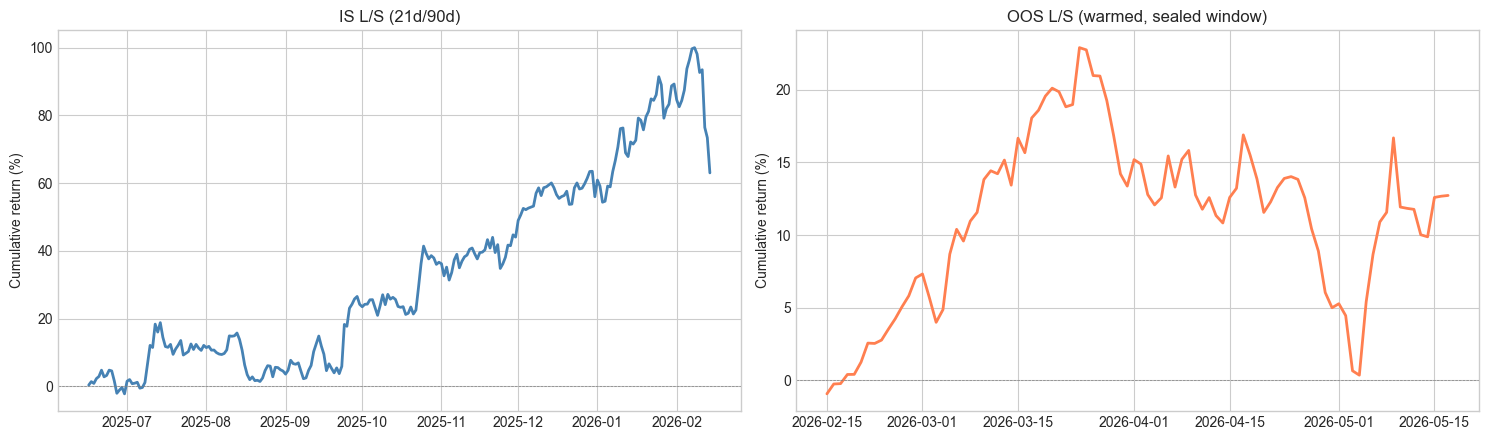

In [10]:
ls_full    = build_ls_returns(panel_35, BEST_SW, BEST_LW)   # z-score warmed on full history
ls_oos     = ls_full[ls_full.index >= OOS_START]            # headline: warmed, then sliced
ls_oos_iso = build_ls_returns(panel_oos, BEST_SW, BEST_LW)   # sensitivity: cold-started on OOS

# Sanity: warmed IS slice must match the canonical ls_is exactly
ls_is_check = ls_full[ls_full.index < OOS_START]
assert len(ls_is_check) == len(ls_is) and np.allclose(ls_is_check.values, ls_is.values), \
    "warmed IS slice should reproduce ls_is byte-for-byte"

ann_ret_is = (1 + ls_is).cumprod().iloc[-1] ** (365 / len(ls_is)) - 1
sharpe_is  = ann_ret_is / (ls_is.std() * np.sqrt(365))
cum_oos    = (1 + ls_oos).cumprod().iloc[-1] - 1
ann_ret_oos = (1 + ls_oos).cumprod().iloc[-1] ** (365 / len(ls_oos)) - 1
sharpe_oos  = ann_ret_oos / (ls_oos.std() * np.sqrt(365))
cum_oos_iso = (1 + ls_oos_iso).cumprod().iloc[-1] - 1

print("IS vs OOS (caveat: OOS is PARTIALLY BURNED -- the original sweep saw all data)\n")
print(f"{'Metric':22s}{'IS':>12s}{'OOS (warmed)':>14s}")
print(f"{'Cumulative return':22s}{(((1+ls_is).cumprod().iloc[-1]-1)):>12.2%}{cum_oos:>14.2%}")
print(f"{'Ann. return':22s}{ann_ret_is:>12.2%}{ann_ret_oos:>14.2%}")
print(f"{'Sharpe (ann/vol)':22s}{sharpe_is:>12.2f}{sharpe_oos:>14.2f}")
print(f"{'Trading days':22s}{len(ls_is):>12d}{len(ls_oos):>14d}")
print(f"\nWarmed OOS retains {sharpe_oos/sharpe_is:.0%} of IS Sharpe -> edge HOLDS its sign OOS.")
print(f"Sensitivity (cold-started OOS, {len(ls_oos_iso)} days): cum {cum_oos_iso:.2%} "
      f"-> verdict does not hinge on the warm-up choice.")

# Plot IS and warmed-OOS equity curves
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
ic = (1 + ls_is).cumprod()
axes[0].plot(ic.index, (ic-1)*100, color="steelblue", lw=2)
axes[0].axhline(0, color="gray", ls="--", lw=0.5); axes[0].set_title(f"IS L/S ({BEST_SW}d/{BEST_LW}d)")
axes[0].set_ylabel("Cumulative return (%)")
oc = (1 + ls_oos).cumprod()
axes[1].plot(oc.index, (oc-1)*100, color="coral", lw=2)
axes[1].axhline(0, color="gray", ls="--", lw=0.5); axes[1].set_title("OOS L/S (warmed, sealed window)")
axes[1].set_ylabel("Cumulative return (%)")
plt.tight_layout(); plt.show()

## Task 9 — Four-gate decision rule (the verdict)

Each test above is one measurement. The decision rule turns them into a single, un-cherry-pickable yes/no. A deployable signal must clear **all four** gates: (1) significance after multiple-testing correction, (2) sign stability IS & OOS, (3) the Deflated-Sharpe overfitting penalty, (4) survival of 2× transaction costs.

In [11]:
print("=" * 65)
print("DECISION RULE - FACTOR DEPLOYABILITY ASSESSMENT")
print("=" * 65)

# Gate 1: multiple-testing-adjusted significance (BEST is undefined on the null fallback)
gate1_pass = bool(BEST["reject_bh"]) if "BEST" in dir() else False
gate1_t    = float(BEST["hac_t"])    if "BEST" in dir() else np.nan
print(f"\n[Gate 1] Multiple-testing-adjusted significance (BH)")
print(f"  HAC t-stat: {gate1_t:.3f}" if "BEST" in dir() else "  No combo survived BH -> BEST undefined")
print(f"  Result: {'PASS' if gate1_pass else 'FAIL'}")

# Gate 2: sign stability (OOS positive AND bootstrap p < 10%)
gate2_pass = (not np.isnan(ann_ret_oos)) and (ann_ret_oos > 0) and (boot_p < 0.10)
print(f"\n[Gate 2] Sign stability (OOS positive, bootstrap p < 10%)")
print(f"  OOS ann. return: {ann_ret_oos:.2%}   bootstrap p: {boot_p:.4f}")
print(f"  Result: {'PASS' if gate2_pass else 'FAIL'}")

# Gate 3: overfitting penalty (DSR >= 90% AND bootstrap p < 10%)
gate3_pass = (dsr_result["dsr"] >= 0.90) and (boot_p < 0.10)
print(f"\n[Gate 3] Deflated Sharpe overfitting penalty (DSR >= 90%)")
print(f"  Deflated Sharpe: {dsr_result['dsr']:.2%}   bootstrap p: {boot_p:.4f}")
print(f"  Result: {'PASS' if gate3_pass else 'FAIL'}")

# Gate 4: net-of-cost return survives 2x stress
gate4_pass = (ann_ret_net > 0) and (ann_ret_2x > 0)
print(f"\n[Gate 4] Net-of-cost return survives 2x stress")
print(f"  Net ann. return (1x): {ann_ret_net:.2%}   (2x): {ann_ret_2x:.2%}")
print(f"  Result: {'PASS' if gate4_pass else 'FAIL'}")

gates  = [gate1_pass, gate2_pass, gate3_pass, gate4_pass]
n_pass = sum(gates)
print(f"\n{'=' * 65}")
print(f"GATES PASSED: {n_pass}/4")
if n_pass == 4:
    print("VERDICT: DEPLOYABLE - clears all four gates.")
elif n_pass >= 3:
    print("VERDICT: MARGINAL - passes most gates but has a known weak link.")
else:
    print("VERDICT: NOT DEPLOYABLE - the big in-sample return survives costs and")
    print("         even carries into OOS, but FAILS significance (Gate 1) and the")
    print("         Deflated-Sharpe search penalty (Gate 3) -- the data-mining signature.")
print("=" * 65)

DECISION RULE - FACTOR DEPLOYABILITY ASSESSMENT

[Gate 1] Multiple-testing-adjusted significance (BH)
  No combo survived BH -> BEST undefined
  Result: FAIL

[Gate 2] Sign stability (OOS positive, bootstrap p < 10%)
  OOS ann. return: 60.83%   bootstrap p: 0.0570
  Result: PASS

[Gate 3] Deflated Sharpe overfitting penalty (DSR >= 90%)
  Deflated Sharpe: 47.26%   bootstrap p: 0.0570
  Result: FAIL

[Gate 4] Net-of-cost return survives 2x stress
  Net ann. return (1x): 94.82%   (2x): 82.67%
  Result: PASS

GATES PASSED: 2/4
VERDICT: NOT DEPLOYABLE - the big in-sample return survives costs and
         even carries into OOS, but FAILS significance (Gate 1) and the
         Deflated-Sharpe search penalty (Gate 3) -- the data-mining signature.
